In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, random
import cv2
from PIL import Image
from tqdm.notebook import tqdm

In [23]:
train_dir = r"C:\Users\Shubham\02 DL project\brain mri tumor\Training"
test_dir = r"C:\Users\Shubham\02 DL project\brain mri tumor\Testing"

In [24]:
for label in os.listdir(train_dir):
    print(f'{label} test image : {len(os.listdir(os.path.join(train_dir, label)))}')

glioma test image : 1400
meningioma test image : 1400
notumor test image : 1400
pituitary test image : 1400


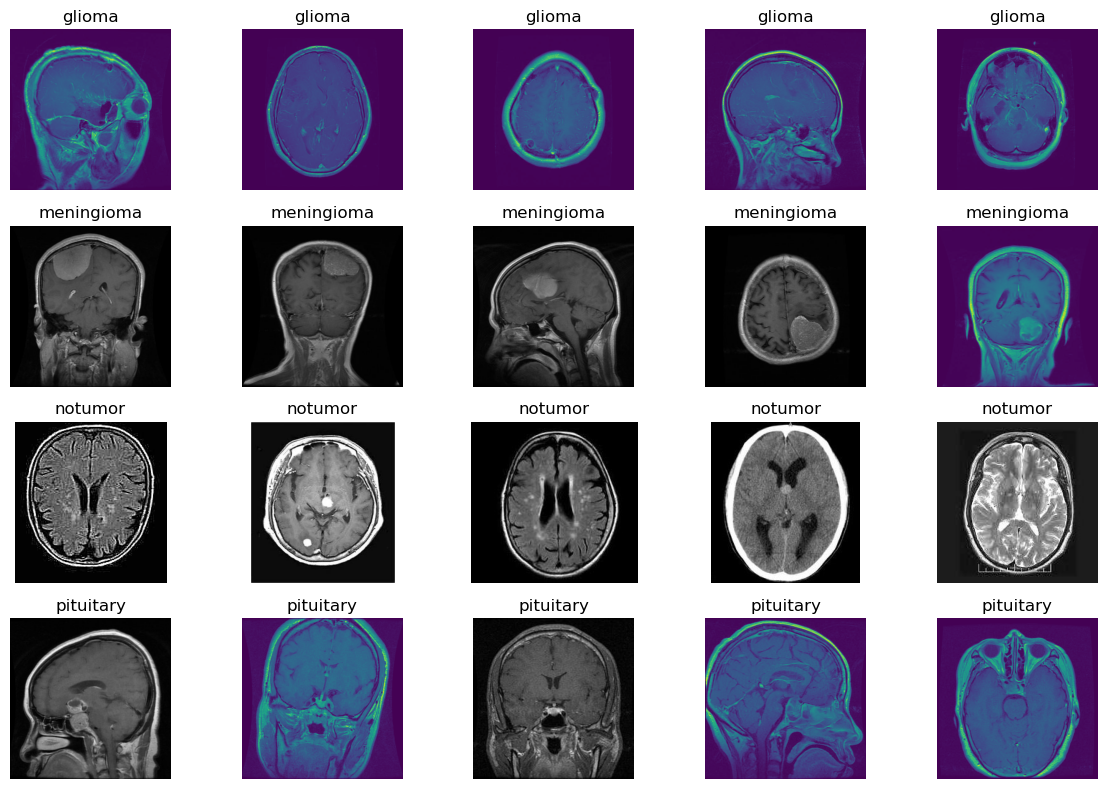

In [25]:
number_of_imgs = 5
classes = os.listdir(train_dir)

plt.figure(figsize = (12, 8))
i = 1

for cls in classes:
    path = os.path.join(train_dir, cls)
    imgs = random.sample(os.listdir(path), 
                         min(number_of_imgs, len(os.listdir(path))))
    
    for img in imgs:
        plt.subplot(len(classes), number_of_imgs, i)
        plt.imshow(Image.open(os.path.join(path, img)))
        plt.title(cls)
        plt.axis('off')
        i += 1

plt.tight_layout()
plt.show()

# Image Preprocess

In [26]:
# constrast enchancement
def applyCLAHE(img):
    clahe = cv2.createCLAHE(clipLimit = 2.0, tileGridSize = (8, 8))
    return clahe.apply(img)

In [27]:
def img_preprocess(img):
    # convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # blur
    gray_blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Otsu threshold
    _, thresh = cv2.threshold(gray_blurred, 0, 255, 
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # contours
    cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(cnts) == 0:
        cropped = gray
    else:
        c = max(cnts, key=cv2.contourArea)

        extLeft = tuple(c[c[:, :, 0].argmin()][0])
        extRight = tuple(c[c[:, :, 0].argmax()][0])
        extTop = tuple(c[c[:, :, 1].argmin()][0])
        extBot = tuple(c[c[:, :, 1].argmax()][0])

        cropped = gray[extTop[1]:extBot[1], extLeft[0]:extRight[0]]

    # resize AFTER crop
    cropped = cv2.resize(cropped, (224, 224))

    # CLAHE
    enhanced = applyCLAHE(cropped)

    return enhanced

In [28]:
output_base = r"C:\Users\Shubham\02 DL project\brain_mri_tumor_prprocessed"

In [29]:
def process_dataset(input_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    classes = [c for c in os.listdir(input_dir)
               if os.path.isdir(os.path.join(input_dir, c))]

    for cls in classes:
        in_cls_path = os.path.join(input_dir, cls)
        out_cls_path = os.path.join(output_dir, cls)

        os.makedirs(out_cls_path, exist_ok=True)

        images = os.listdir(in_cls_path)

        for img_name in tqdm(images, desc=f"{cls}"):

            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            img_path = os.path.join(in_cls_path, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            processed = img_preprocess(img)

            if processed.dtype != np.uint8:
                processed = processed.astype(np.uint8)

            save_path = os.path.join(out_cls_path, img_name)

            cv2.imwrite(save_path, processed)

process_dataset(train_dir, os.path.join(output_base, "train"))
process_dataset(test_dir, os.path.join(output_base, "test"))

print("✅ All images processed and saved successfully!")

glioma:   0%|          | 0/1400 [00:00<?, ?it/s]

meningioma:   0%|          | 0/1400 [00:00<?, ?it/s]

notumor:   0%|          | 0/1400 [00:00<?, ?it/s]

pituitary:   0%|          | 0/1400 [00:00<?, ?it/s]

glioma:   0%|          | 0/400 [00:00<?, ?it/s]

meningioma:   0%|          | 0/400 [00:00<?, ?it/s]

notumor:   0%|          | 0/400 [00:00<?, ?it/s]

pituitary:   0%|          | 0/400 [00:00<?, ?it/s]

✅ All images processed and saved successfully!


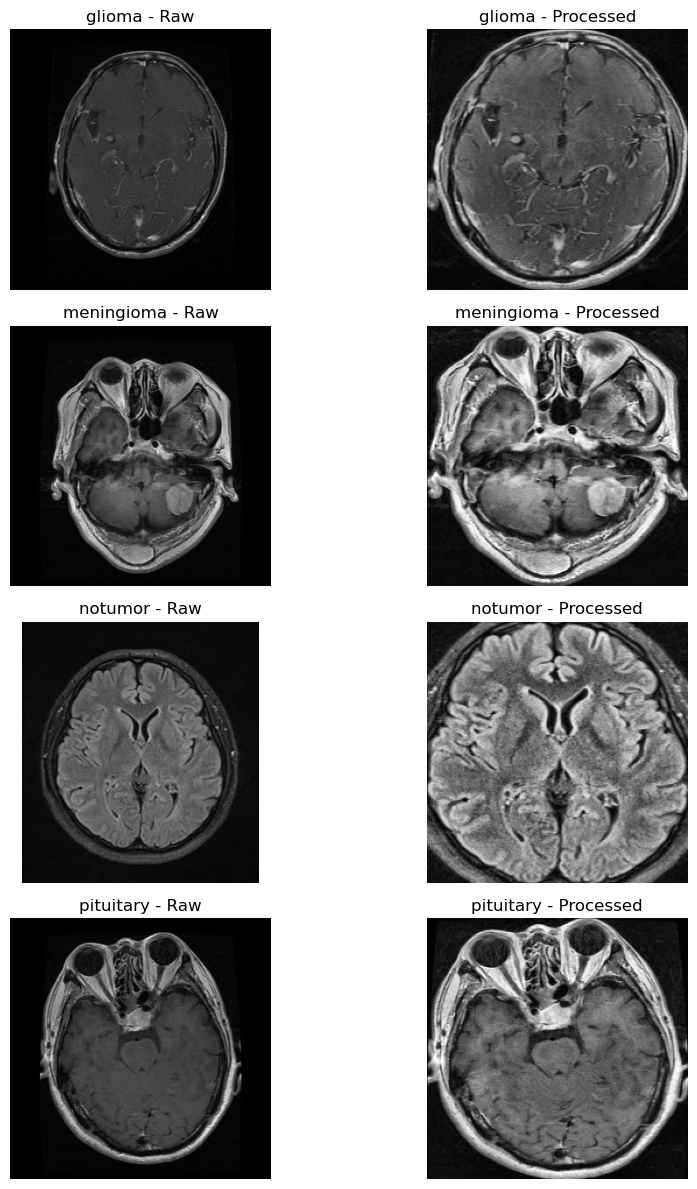

In [56]:
raw_dir = r"C:\Users\Shubham\02 DL project\brain mri tumor\Training"
processed_dir = r"C:\Users\Shubham\02 DL project\brain_mri_tumor_prprocessed\train"

classes = os.listdir(raw_dir)

plt.figure(figsize = (10, 12))

for i, cls in enumerate(classes):
    
    raw_class_path = os.path.join(raw_dir, cls)
    processed_class_path = os.path.join(processed_dir, cls)

    files = os.listdir(raw_class_path)

    file = random.choice(files)

    raw_img = cv2.imread(os.path.join(raw_class_path, file))
    processed_img = cv2.imread(os.path.join(processed_class_path, file))

    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    processed_img = cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB)

    # Raw
    plt.subplot(len(classes), 2, i*2 + 1)
    plt.imshow(raw_img)
    plt.title(f"{cls} - Raw")
    plt.axis("off")

    # Processed
    plt.subplot(len(classes), 2, i*2 + 2)
    plt.imshow(processed_img)
    plt.title(f"{cls} - Processed")
    plt.axis("off")

plt.tight_layout()
plt.show()